# Flow/TMS 시계열 주기성 EDA

이 노트북은 `FLOW_Actual.csv`와 `TMS_Actual.csv`를 사용하여 다음 주기성을 시각적으로 확인합니다.

- 시간대(시)
- 요일
- 주(ISO week)
- 월


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


def setup_korean_font():
    candidate_fonts = [
        "Malgun Gothic",
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    for font_name in candidate_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid")
setup_korean_font()
plt.rcParams["figure.dpi"] = 120


In [6]:
# 경로 기준: python/notebook/EDA
FLOW_PATH = "../../data/actual/FLOW_Actual.csv"
TMS_PATH = "../../data/actual/TMS_Actual.csv"


def load_and_prepare(csv_path: str, time_col: str = "SYS_TIME") -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    if time_col not in df.columns:
        raise ValueError(f"'{time_col}' 컬럼이 없습니다: {csv_path}")

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col]).copy()
    df = df.sort_values(time_col).reset_index(drop=True)

    # 시간 파생 컬럼 생성
    iso = df[time_col].dt.isocalendar()
    df["hour"] = df[time_col].dt.hour
    df["weekday"] = df[time_col].dt.weekday  # 0=월, 6=일
    df["iso_week"] = iso.week.astype(int)
    df["month"] = df[time_col].dt.month

    return df


flow_df = load_and_prepare(FLOW_PATH)
tms_df = load_and_prepare(TMS_PATH)

print("[FLOW]", flow_df.shape)
print("[TMS]", tms_df.shape)
print("\nFLOW 컬럼:\n", flow_df.columns.tolist())
print("\nTMS 컬럼:\n", tms_df.columns.tolist())


[FLOW] (130732, 10)
[TMS] (514551, 11)

FLOW 컬럼:
 ['data_save_dt', 'flow_TankA', 'flow_TankB', 'level_TankA', 'level_TankB', 'SYS_TIME', 'hour', 'weekday', 'iso_week', 'month']

TMS 컬럼:
 ['SYS_TIME', 'TOC_VU', 'PH_VU', 'SS_VU', 'FLUX_VU', 'TN_VU', 'TP_VU', 'hour', 'weekday', 'iso_week', 'month']


In [7]:
WEEKDAY_LABELS = ["월", "화", "수", "목", "금", "토", "일"]


def get_numeric_targets(df: pd.DataFrame, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = ["hour", "weekday", "iso_week", "month"]
    return [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in exclude_cols
    ]


def plot_periodicity(df: pd.DataFrame, value_col: str, dataset_name: str):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"{dataset_name} | {value_col} 주기성", fontsize=14, y=1.02)

    # 1) 시간대 주기성
    hourly = df.groupby("hour", as_index=False)[value_col].mean()
    sns.lineplot(data=hourly, x="hour", y=value_col, marker="o", ax=axes[0, 0], color="#1f77b4")
    axes[0, 0].set_title("시간대 패턴")
    axes[0, 0].set_xlabel("시간")
    axes[0, 0].set_xlim(0, 23)

    # 2) 요일 주기성
    weekday = df.groupby("weekday", as_index=False)[value_col].mean()
    sns.barplot(data=weekday, x="weekday", y=value_col, ax=axes[0, 1], color="#ff7f0e")
    axes[0, 1].set_title("요일 패턴")
    axes[0, 1].set_xlabel("요일")
    axes[0, 1].set_xticks(range(7))
    axes[0, 1].set_xticklabels(WEEKDAY_LABELS)

    # 3) 주(ISO week) 주기성
    weekly = df.groupby("iso_week", as_index=False)[value_col].mean()
    sns.lineplot(data=weekly, x="iso_week", y=value_col, marker=".", ax=axes[1, 0], color="#2ca02c")
    axes[1, 0].set_title("주간 패턴 (ISO week)")
    axes[1, 0].set_xlabel("주차")

    # 4) 월 주기성
    monthly = df.groupby("month", as_index=False)[value_col].mean()
    sns.lineplot(data=monthly, x="month", y=value_col, marker="o", ax=axes[1, 1], color="#d62728")
    axes[1, 1].set_title("월별 패턴")
    axes[1, 1].set_xlabel("월")
    axes[1, 1].set_xticks(range(1, 13))

    for ax in axes.ravel():
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hour_weekday_heatmap(df: pd.DataFrame, value_col: str, dataset_name: str):
    pivot = df.pivot_table(index="weekday", columns="hour", values=value_col, aggfunc="mean")
    pivot = pivot.reindex(index=range(7))

    plt.figure(figsize=(14, 4))
    sns.heatmap(pivot, cmap="YlGnBu", cbar=True)
    plt.title(f"{dataset_name} | {value_col} (요일 x 시간 히트맵)")
    plt.xlabel("시간")
    plt.ylabel("요일")
    plt.yticks(np.arange(7) + 0.5, WEEKDAY_LABELS, rotation=0)
    plt.tight_layout()
    plt.show()


## FLOW 주기성

기본값으로 FLOW의 모든 수치형 컬럼을 시각화합니다.
필요하면 `flow_cols`를 직접 지정해 사용할 수 있습니다.


FLOW targets: ['data_save_dt', 'flow_TankA', 'flow_TankB', 'level_TankA', 'level_TankB']


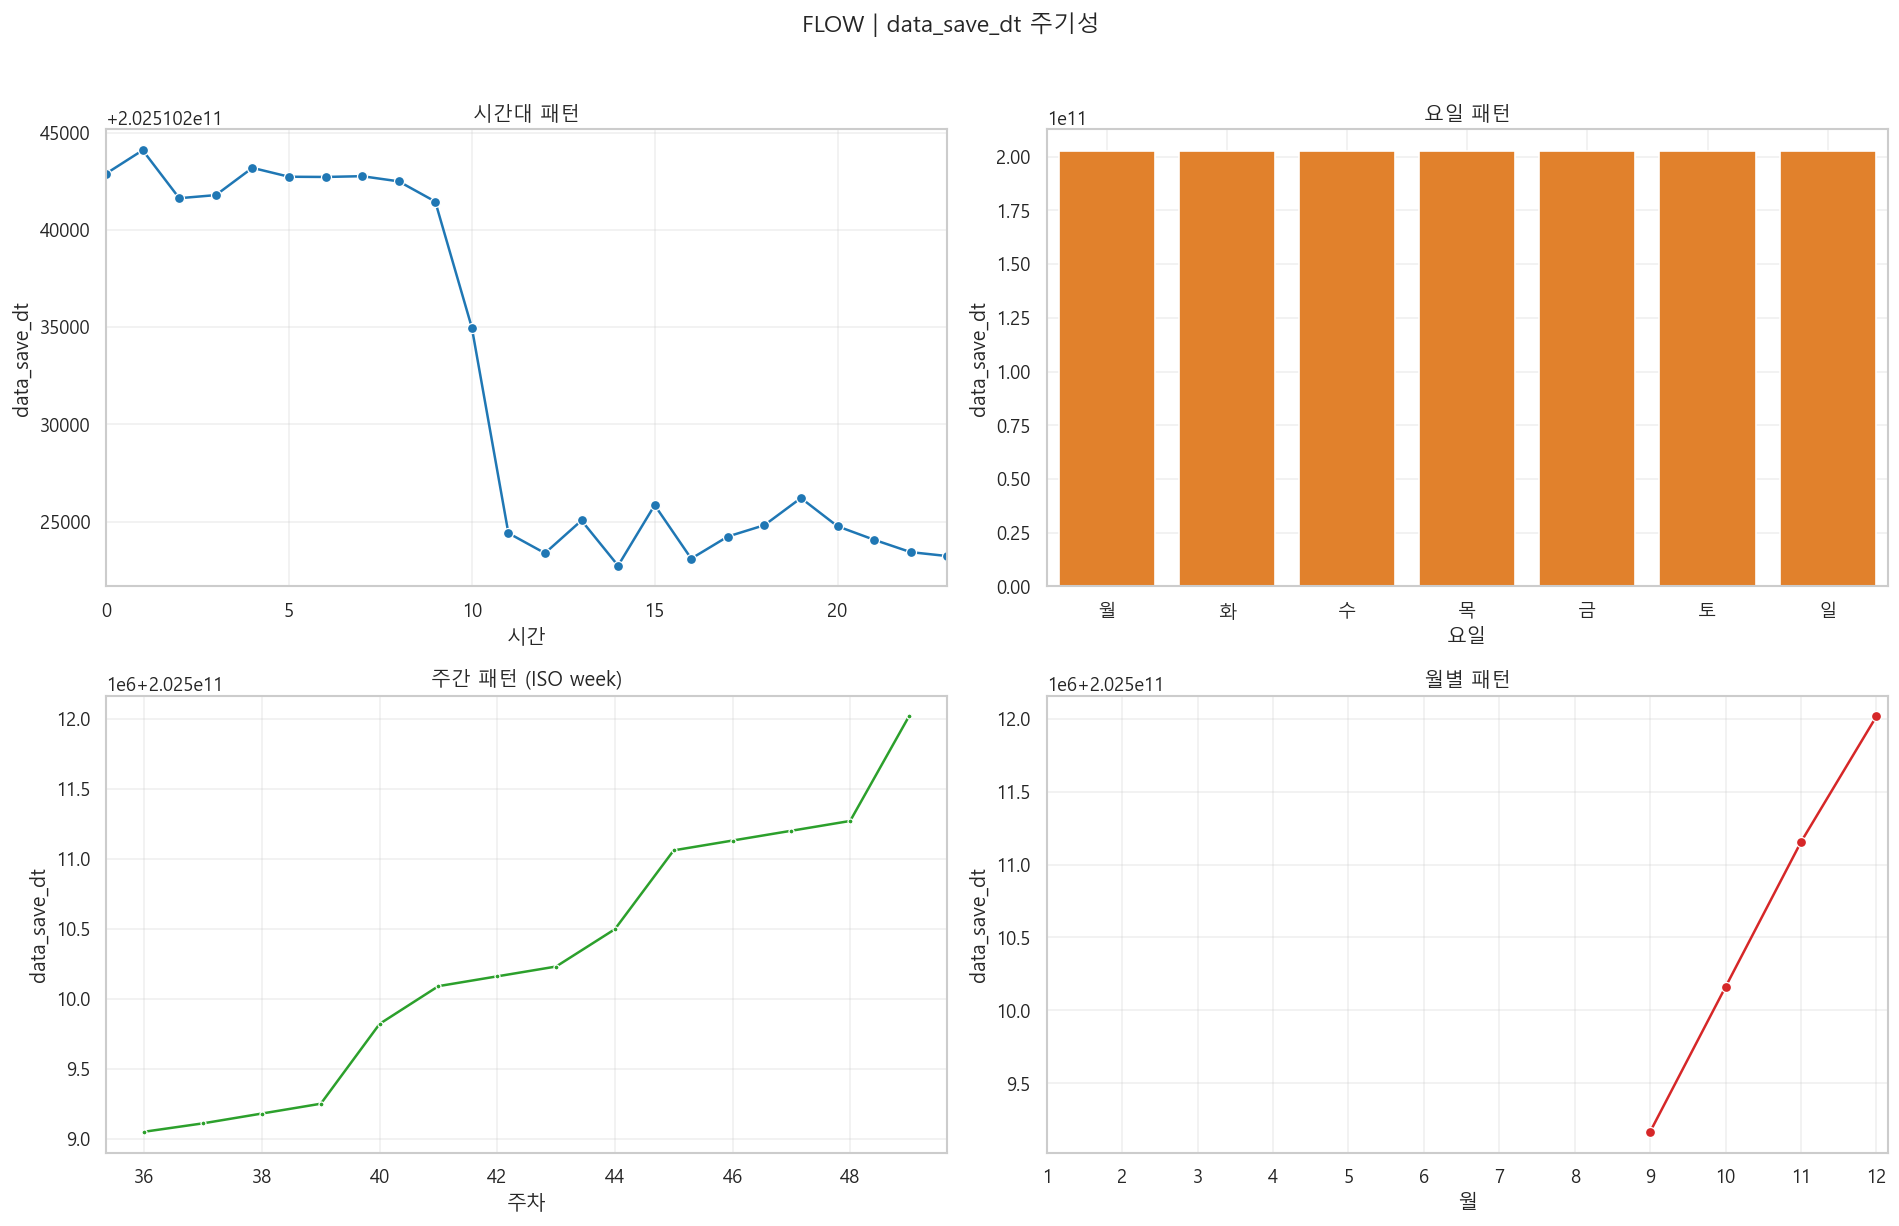

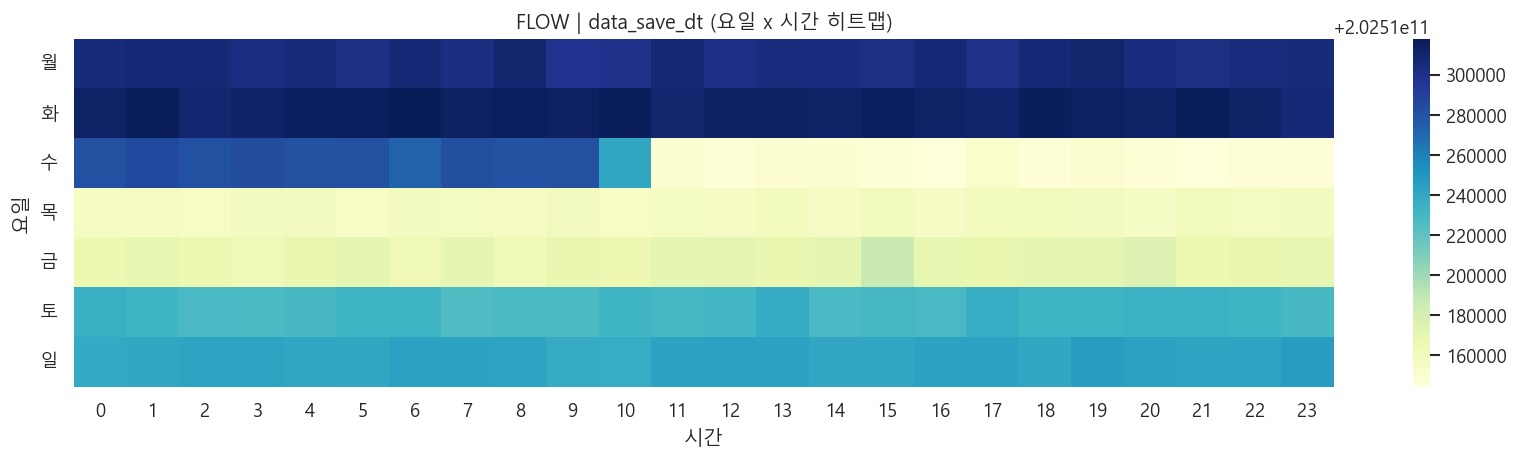

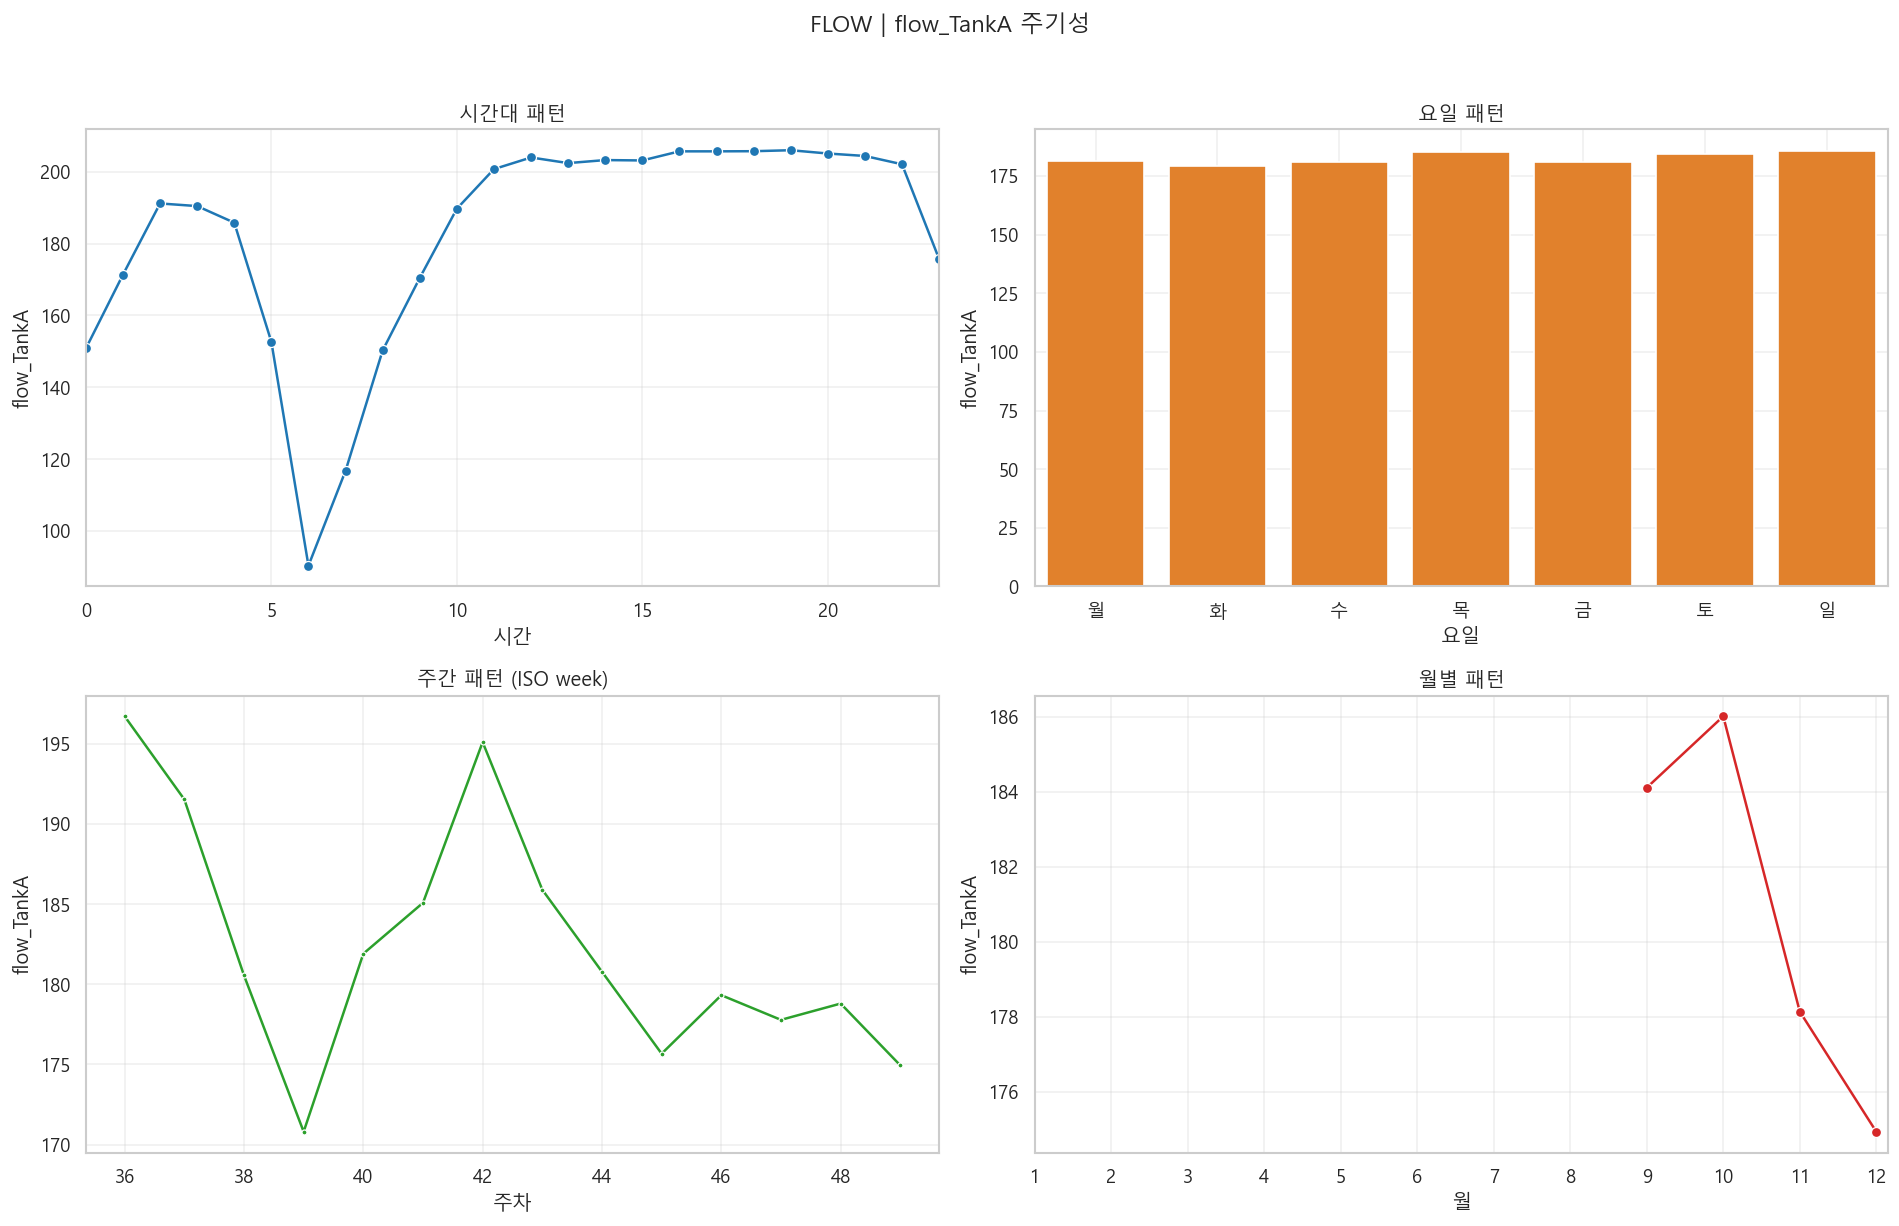

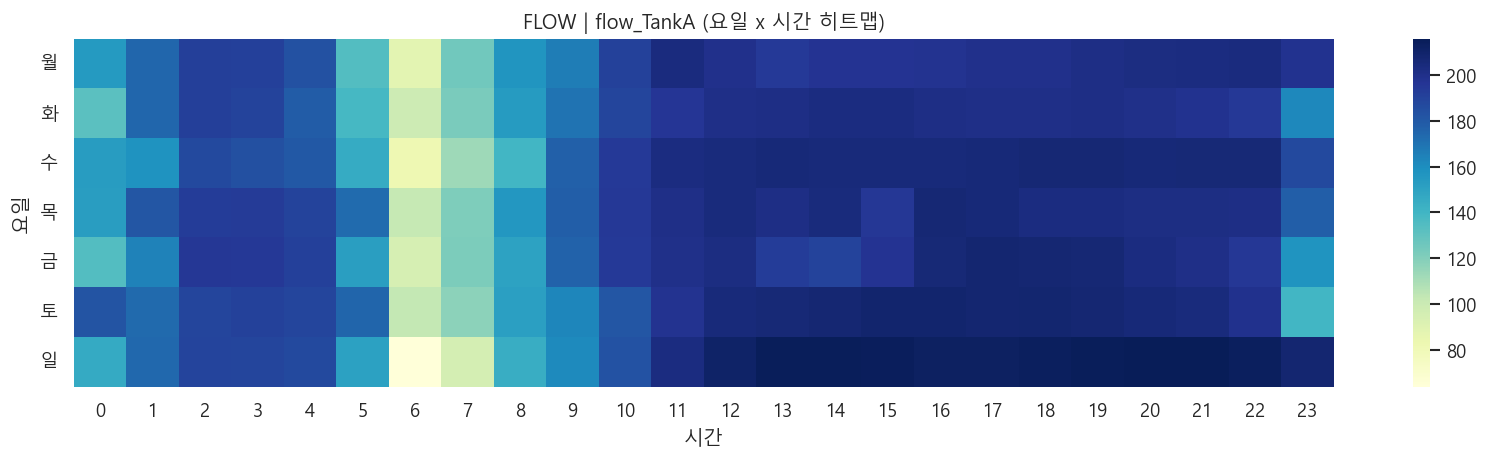

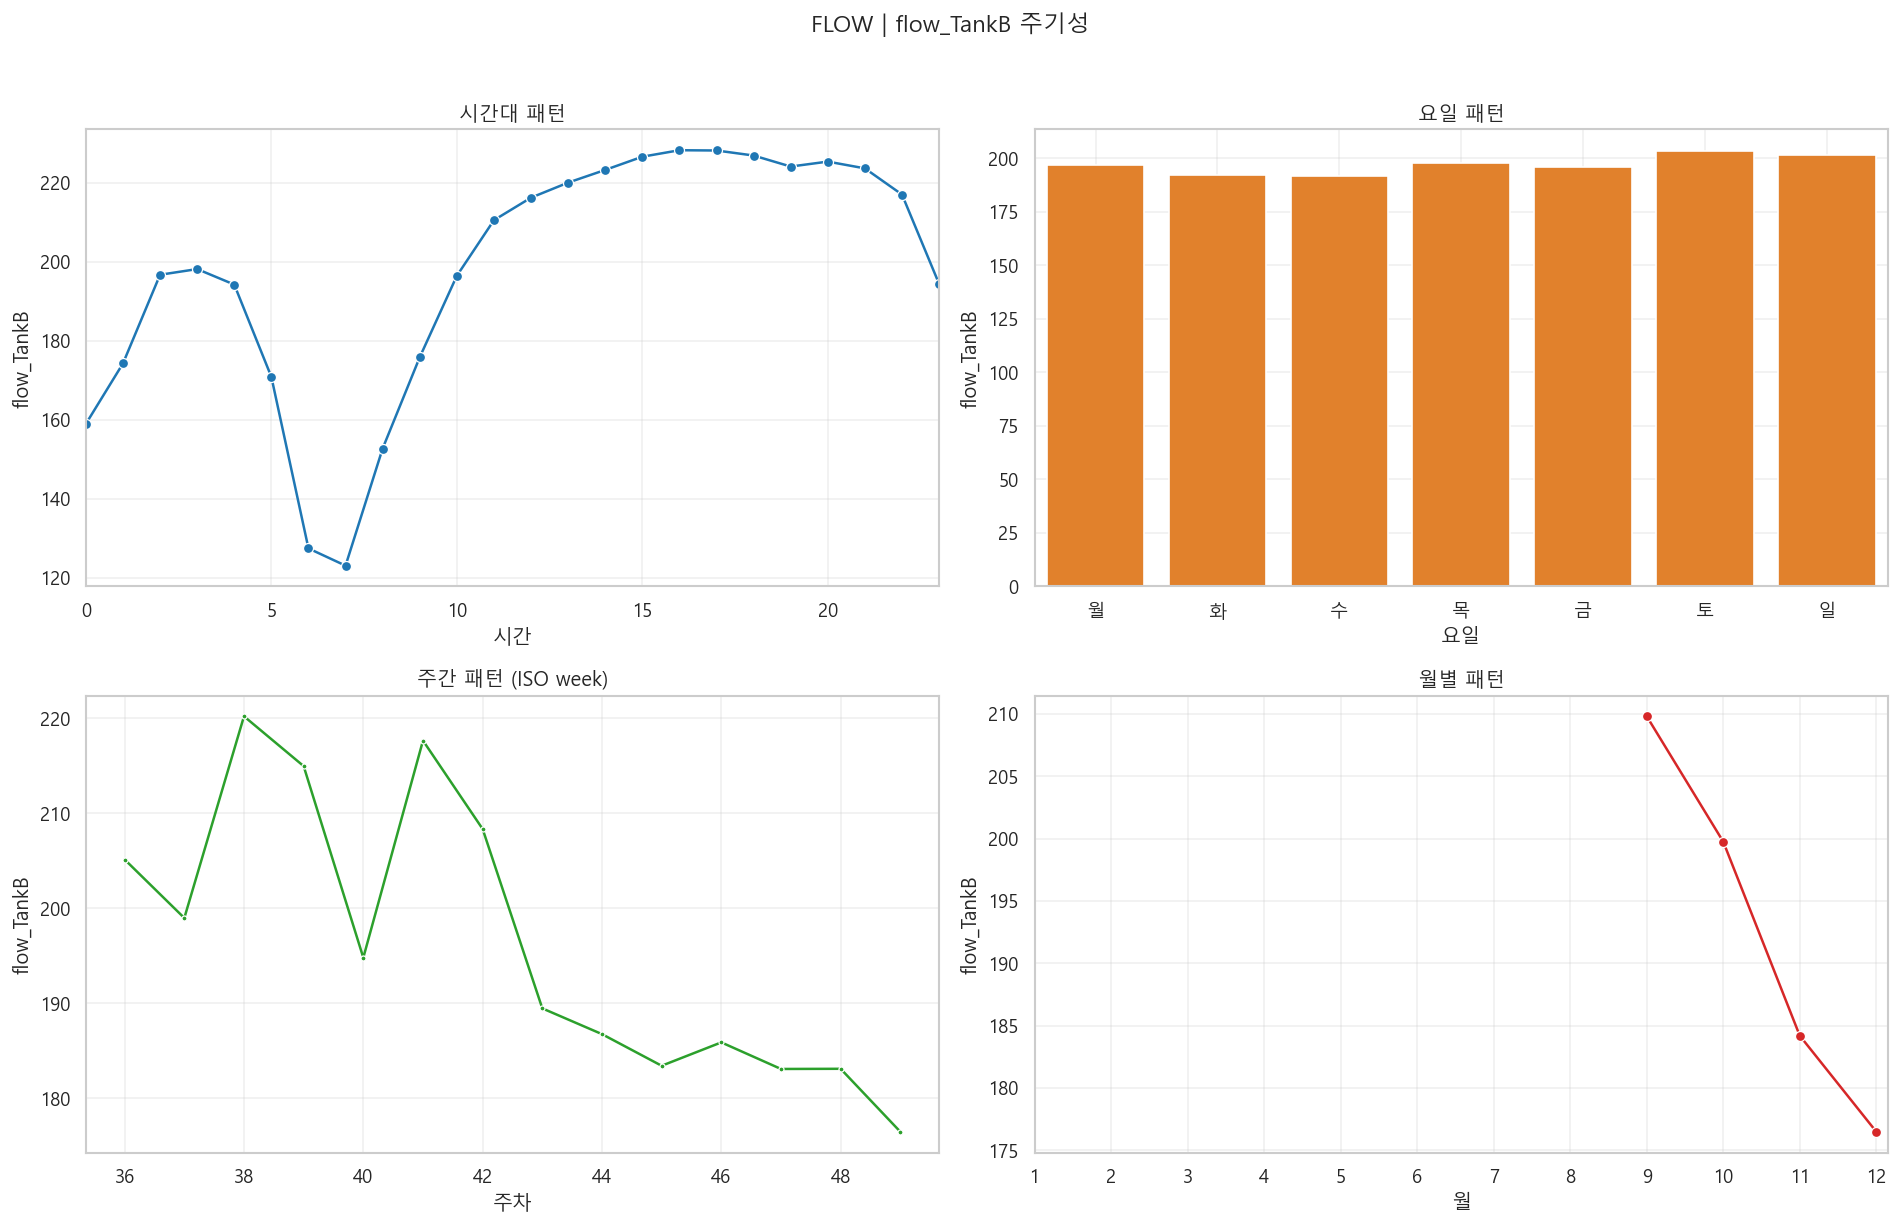

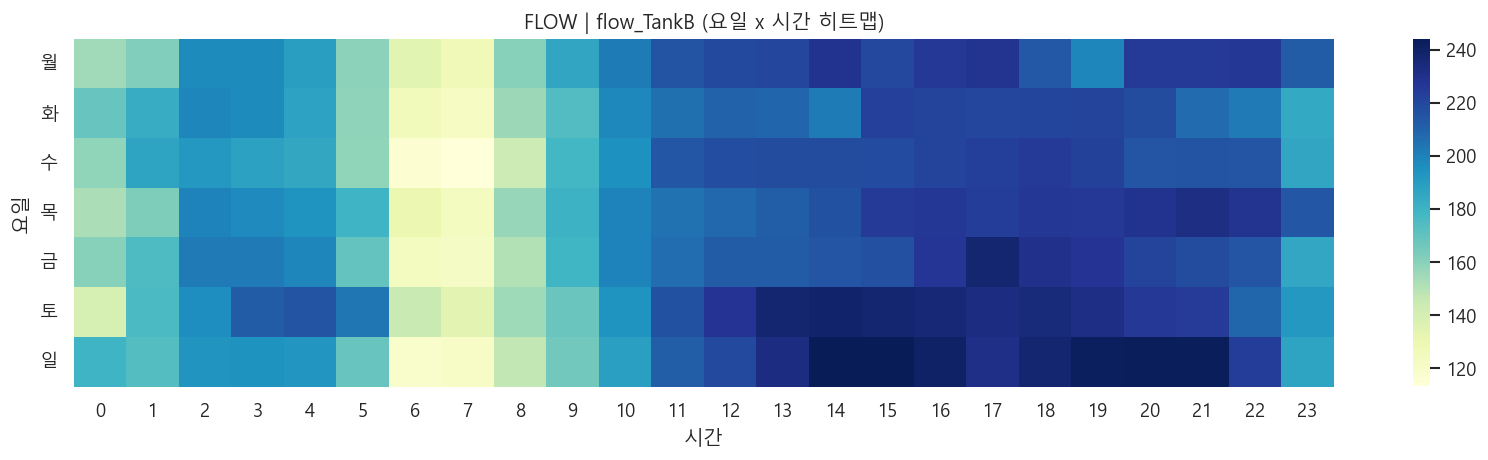

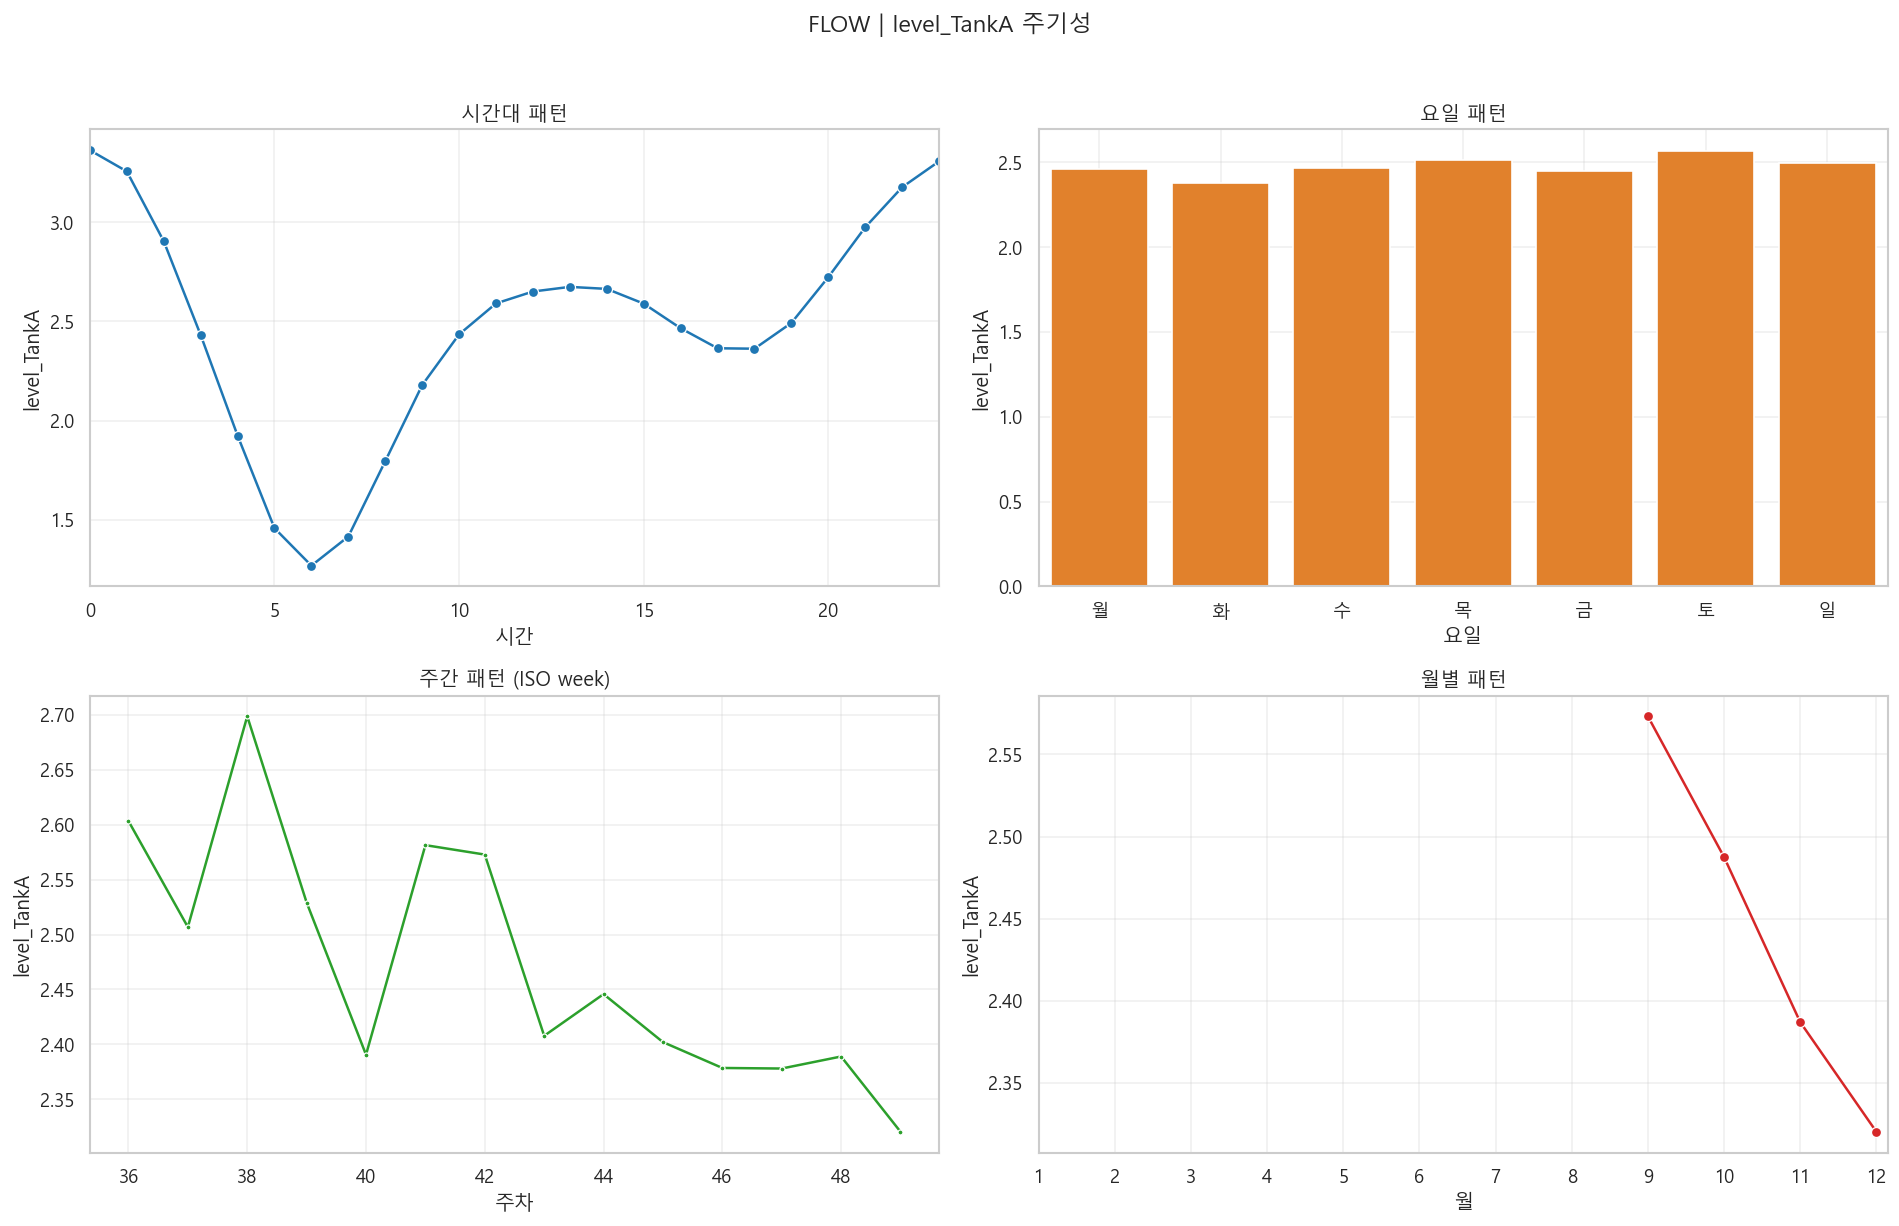

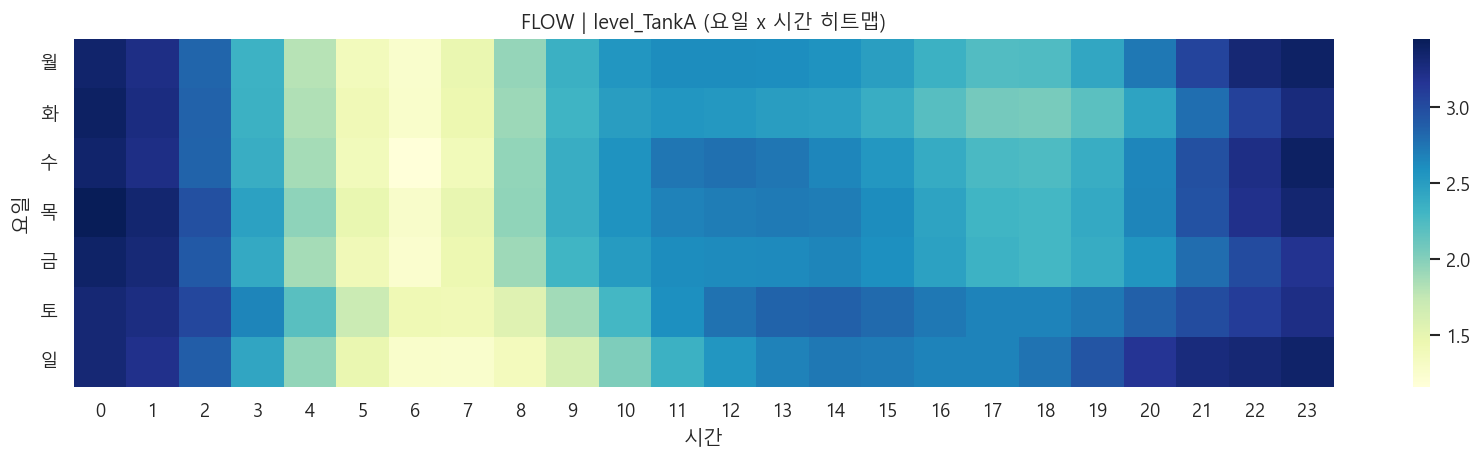

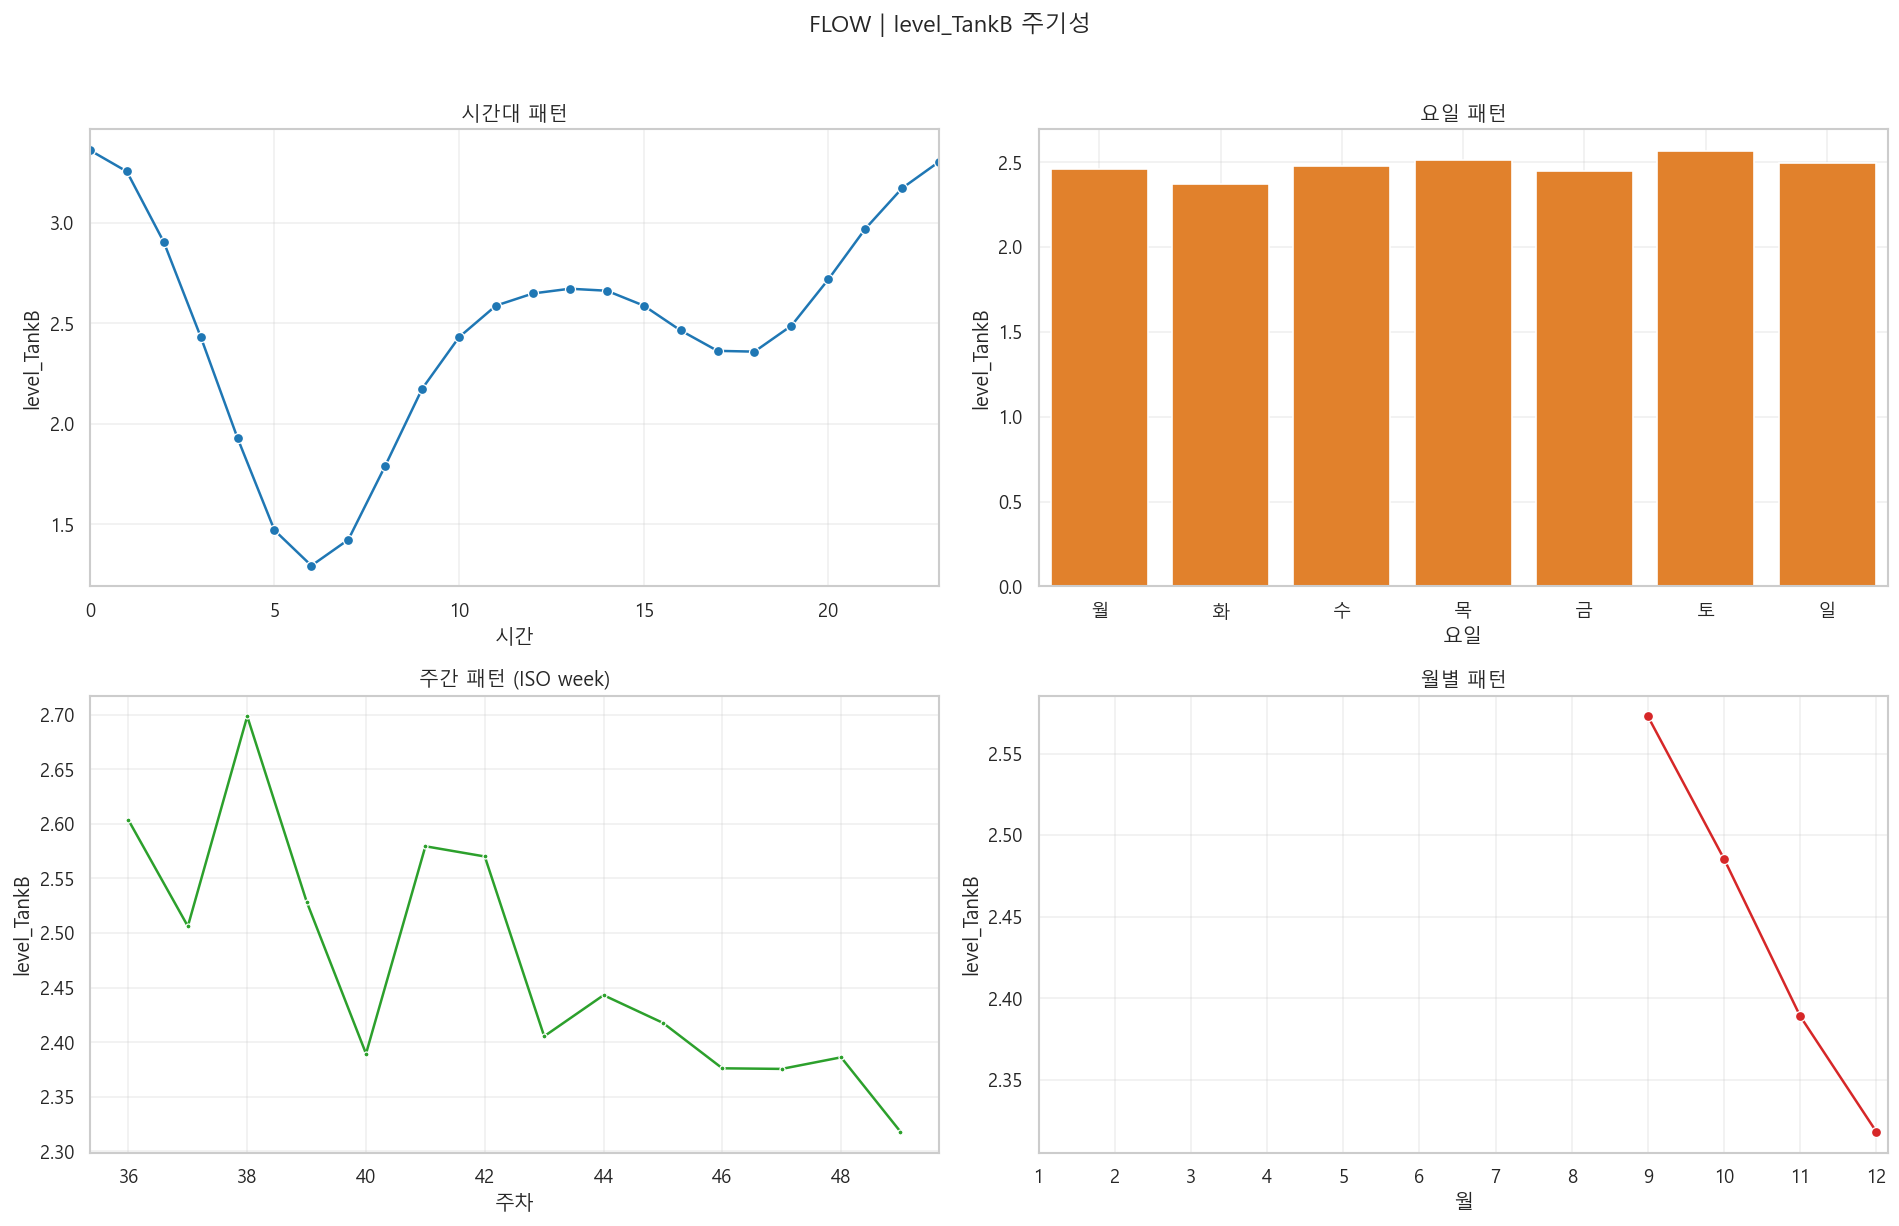

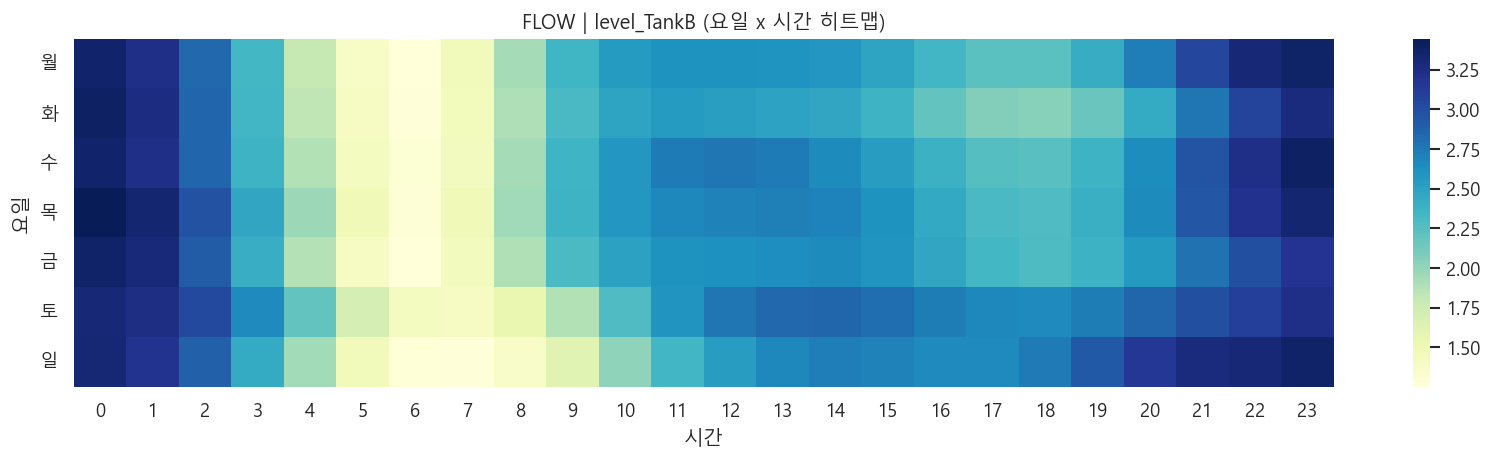

In [8]:
flow_cols = get_numeric_targets(flow_df)
print("FLOW targets:", flow_cols)

for col in flow_cols:
    plot_periodicity(flow_df, col, "FLOW")
    plot_hour_weekday_heatmap(flow_df, col, "FLOW")


## TMS 주기성

기본값으로 TMS의 모든 수치형 컬럼을 시각화합니다.
필요하면 `tms_cols`를 직접 지정해 사용할 수 있습니다.


TMS targets: ['TOC_VU', 'PH_VU', 'SS_VU', 'FLUX_VU', 'TN_VU', 'TP_VU']


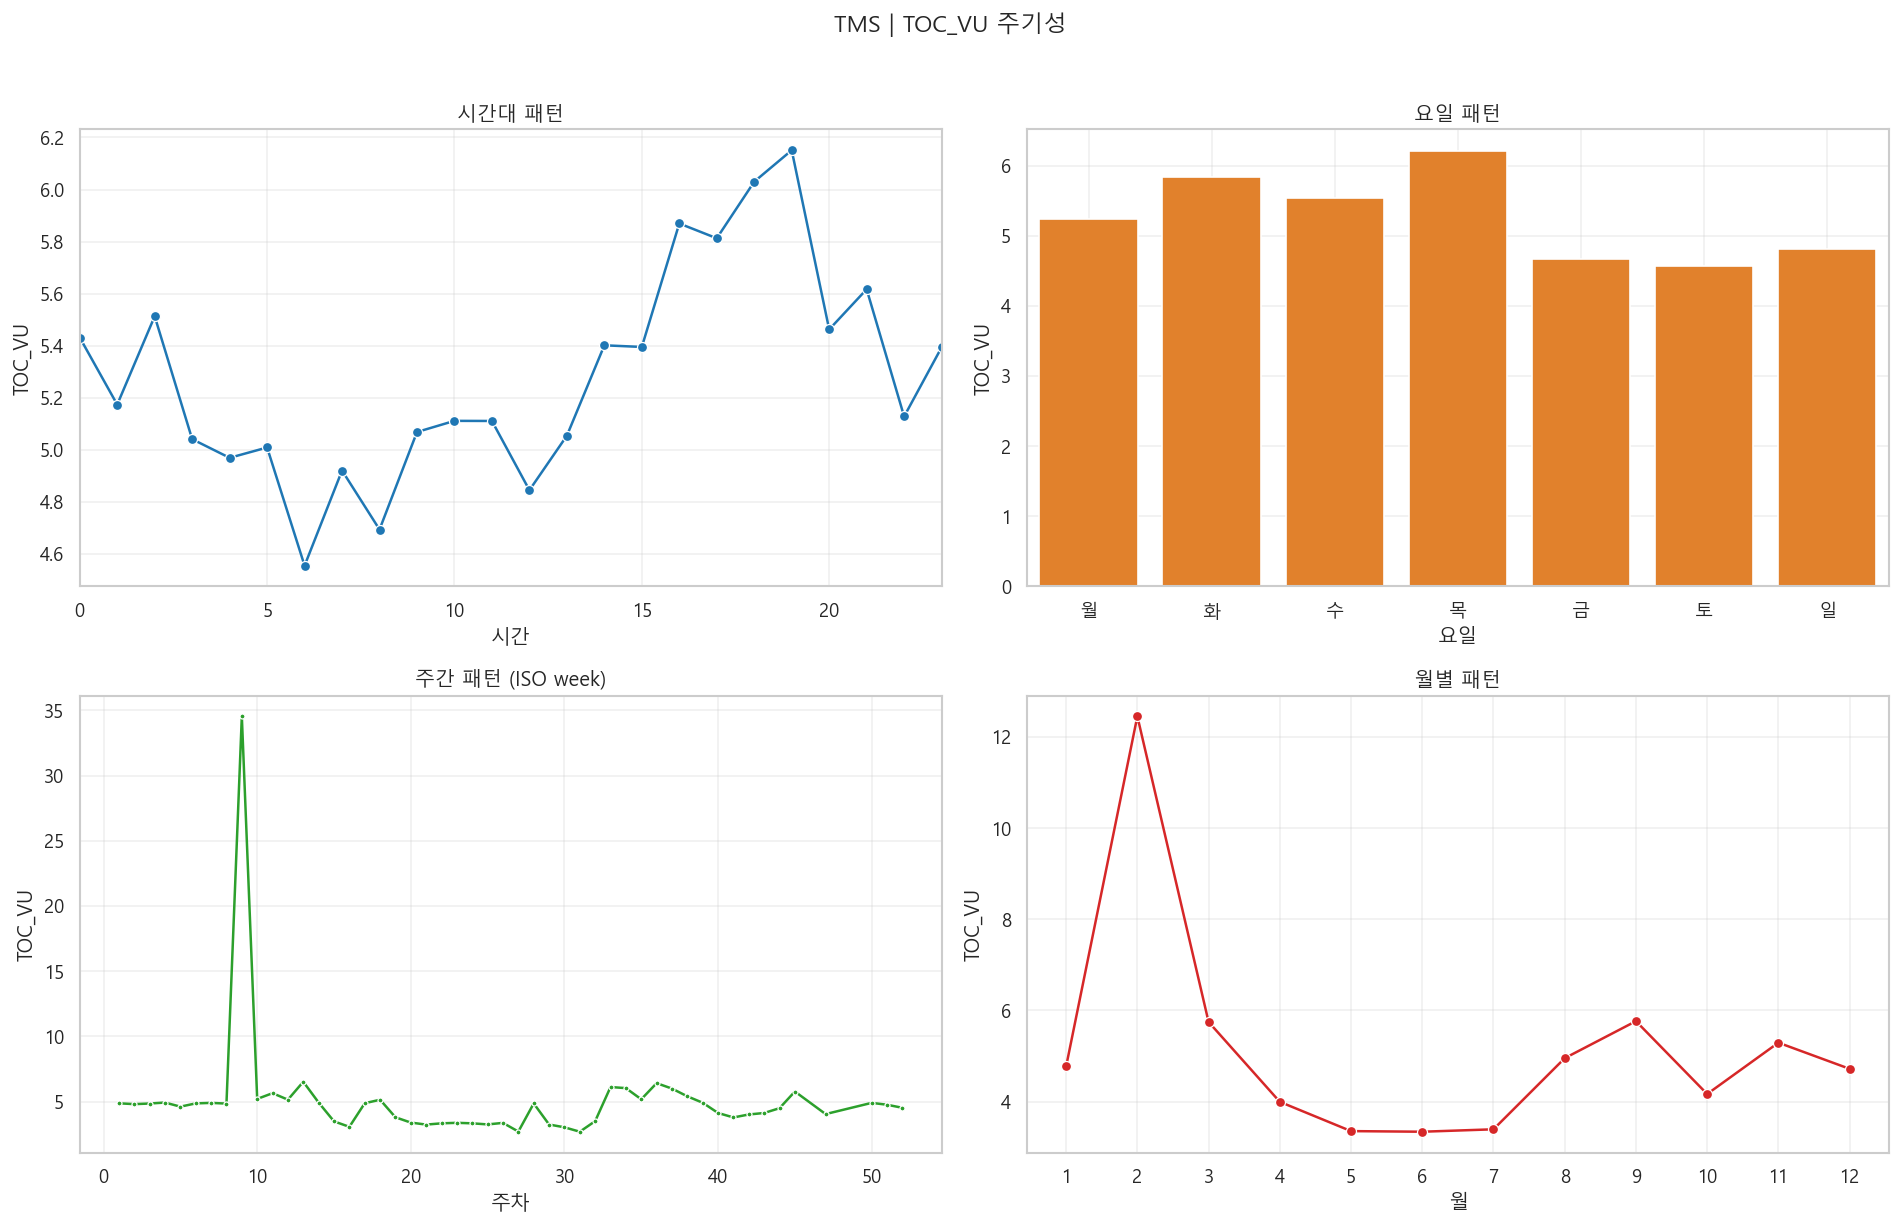

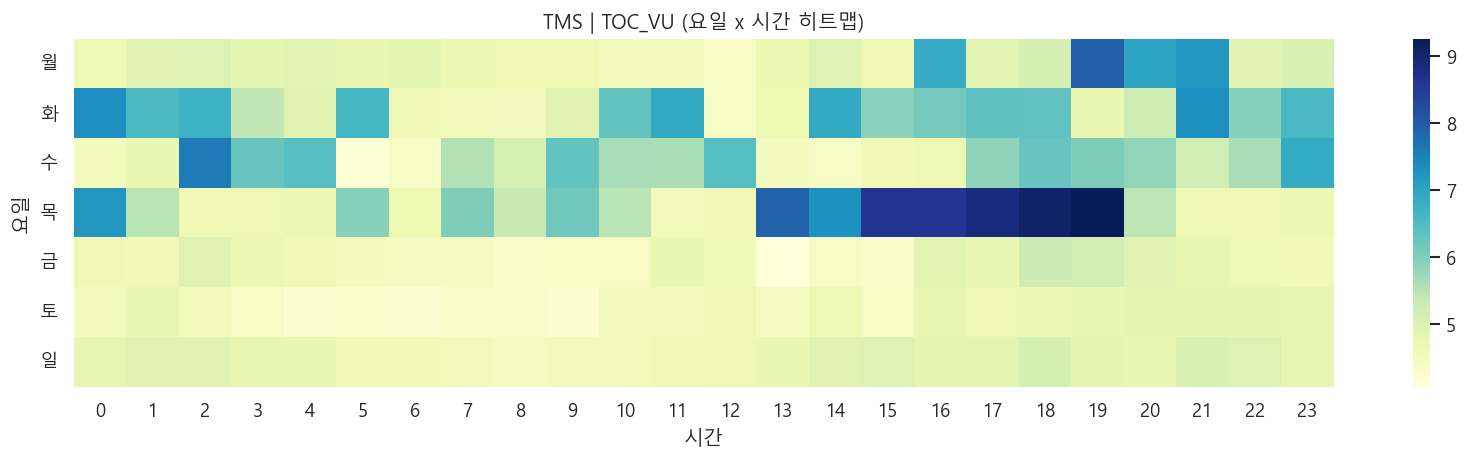

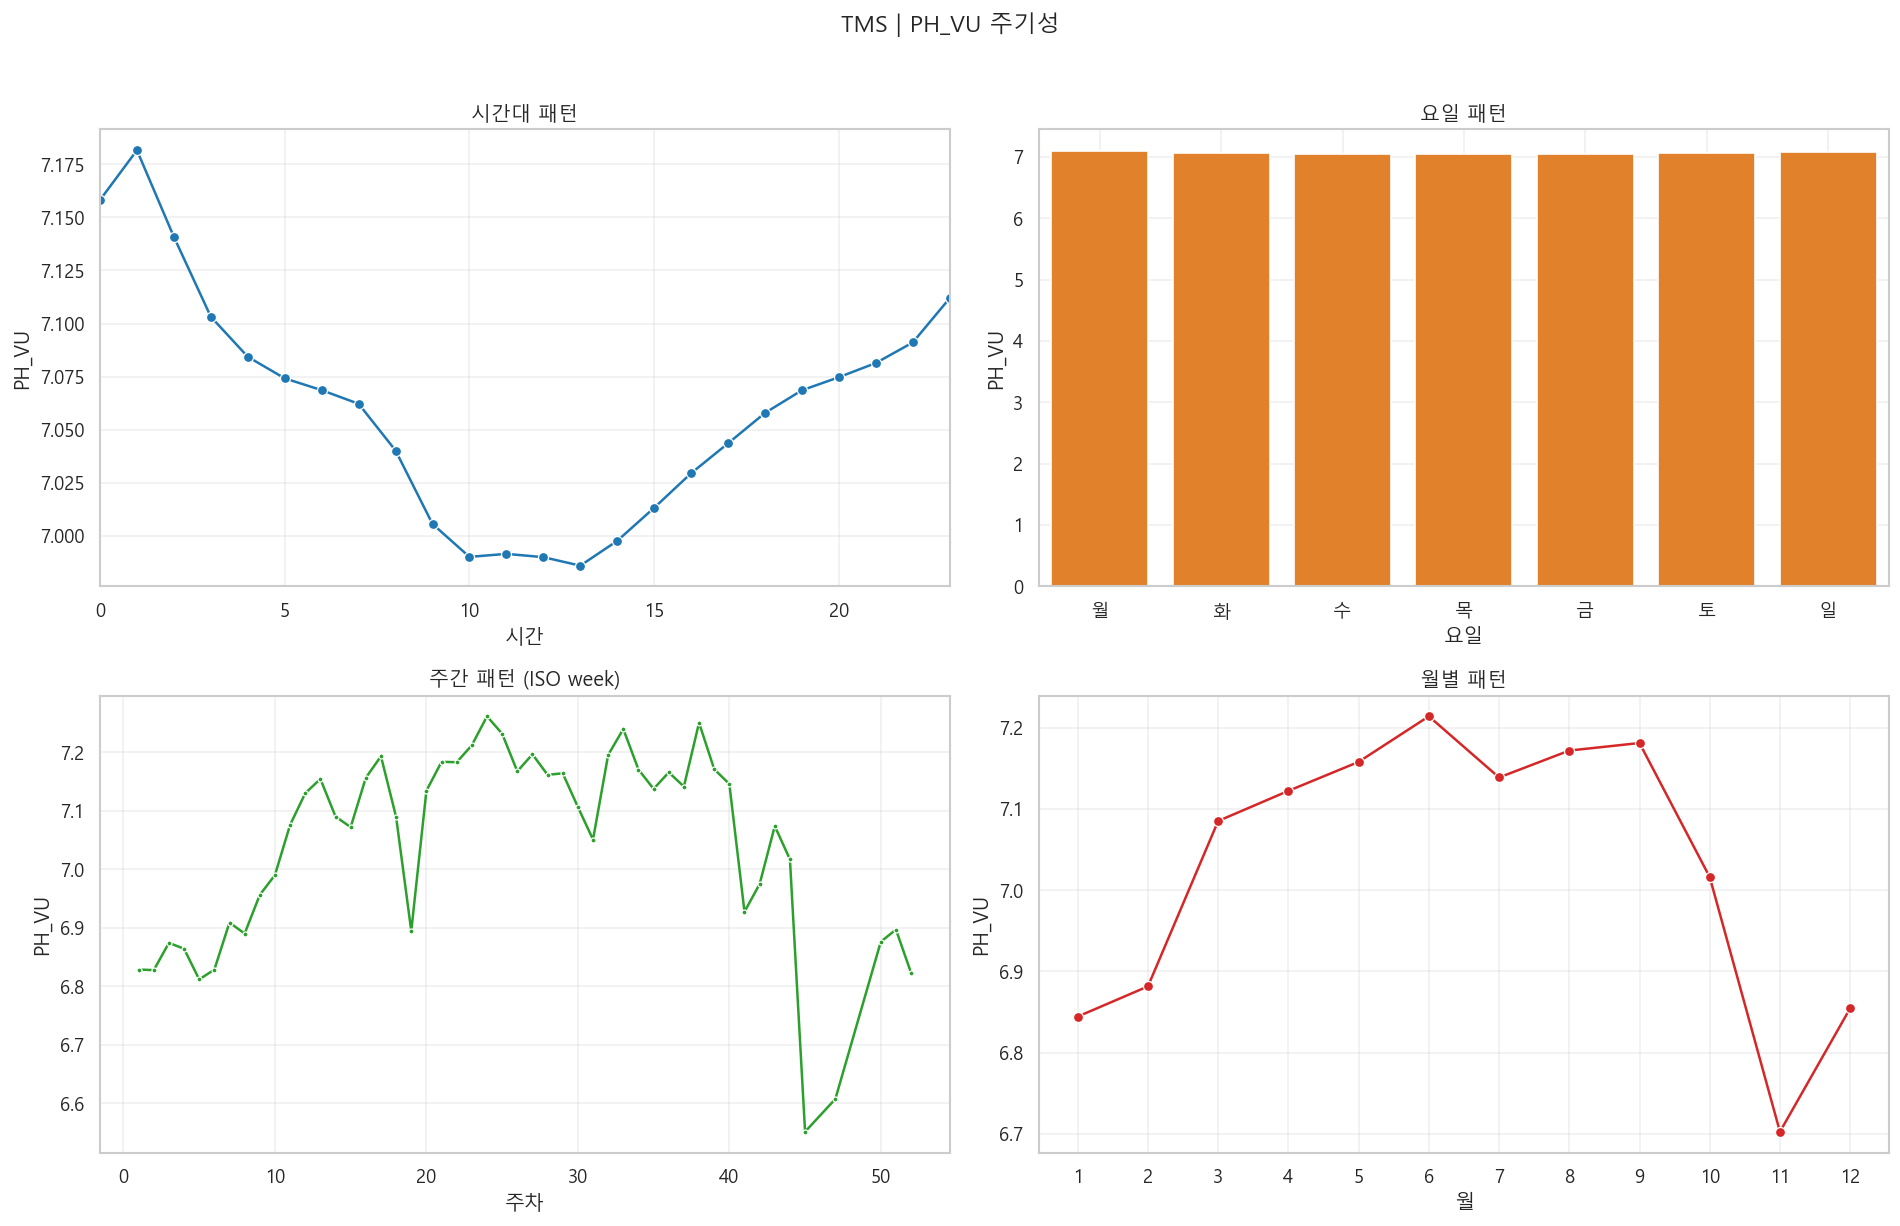

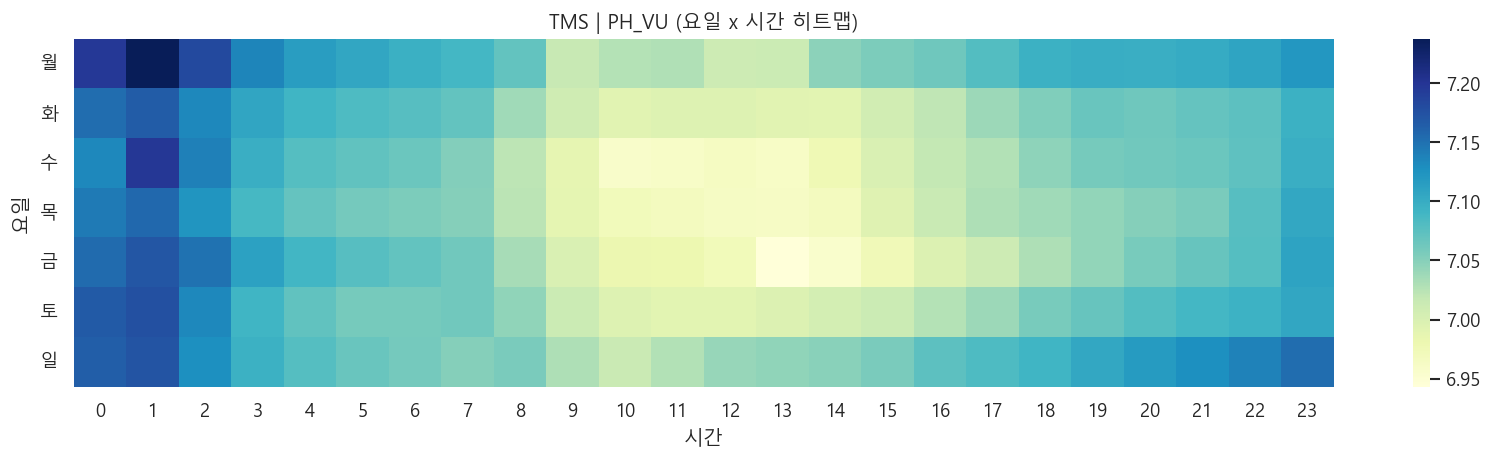

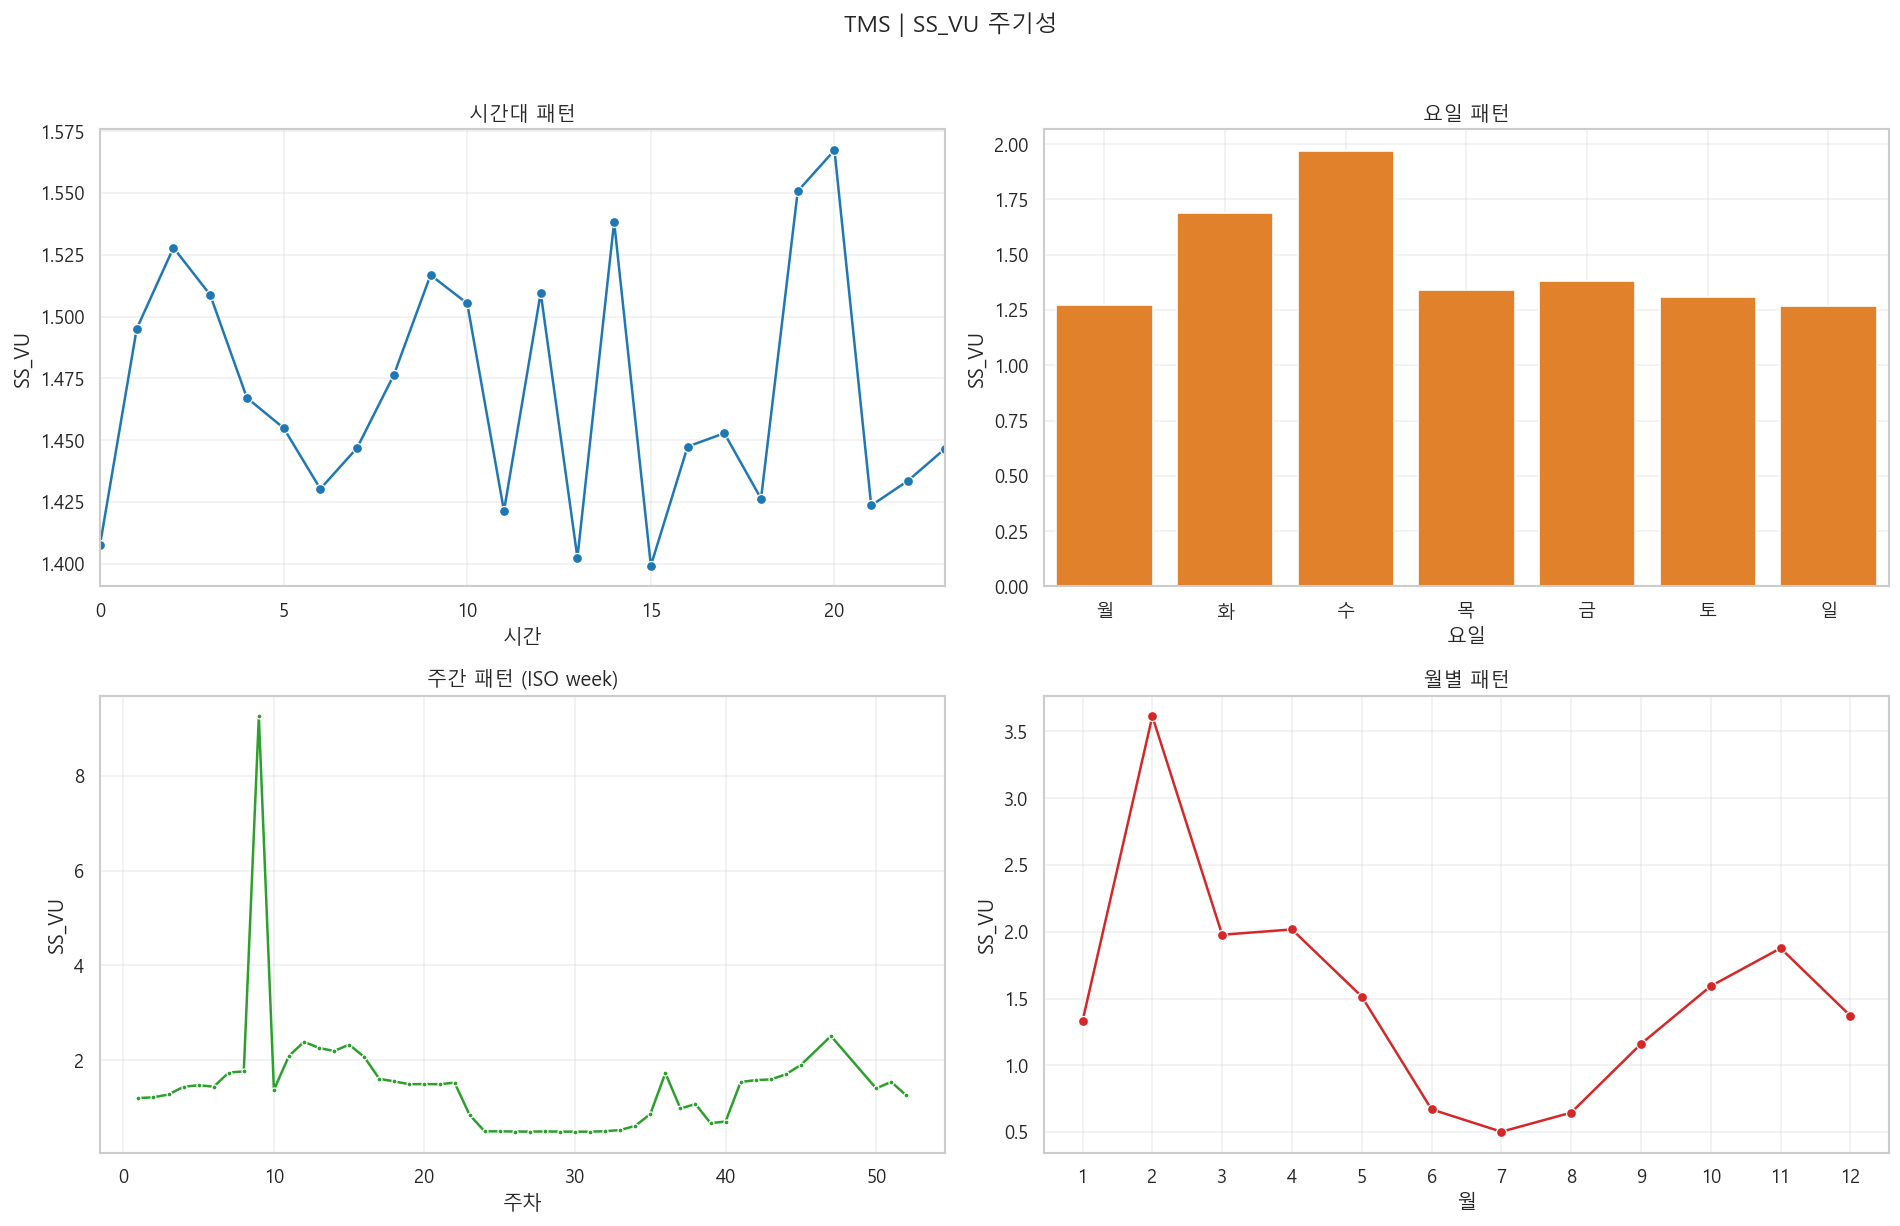

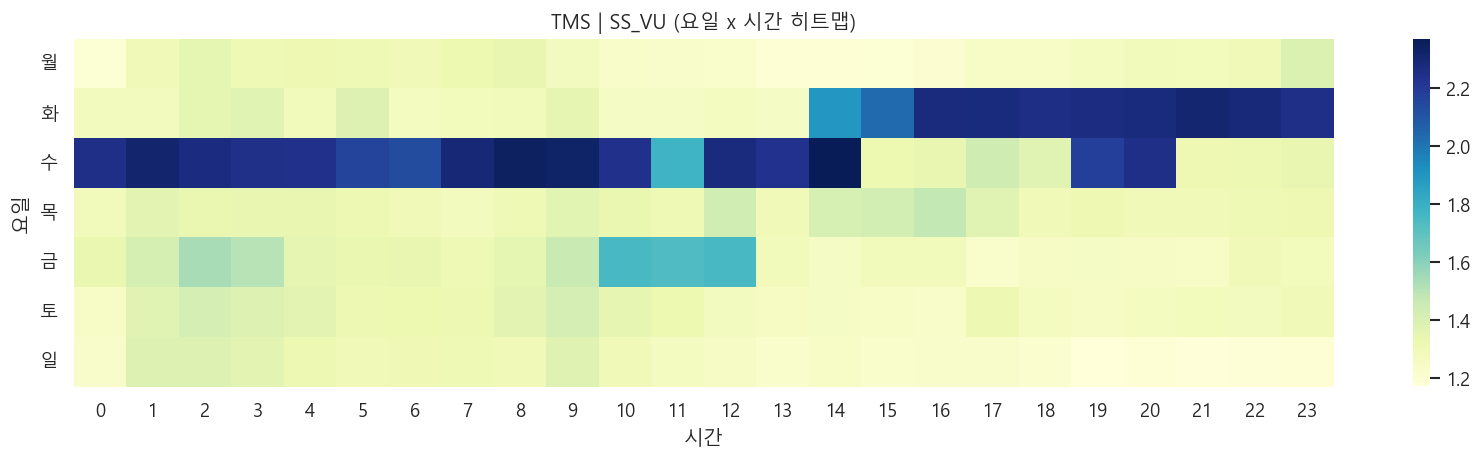

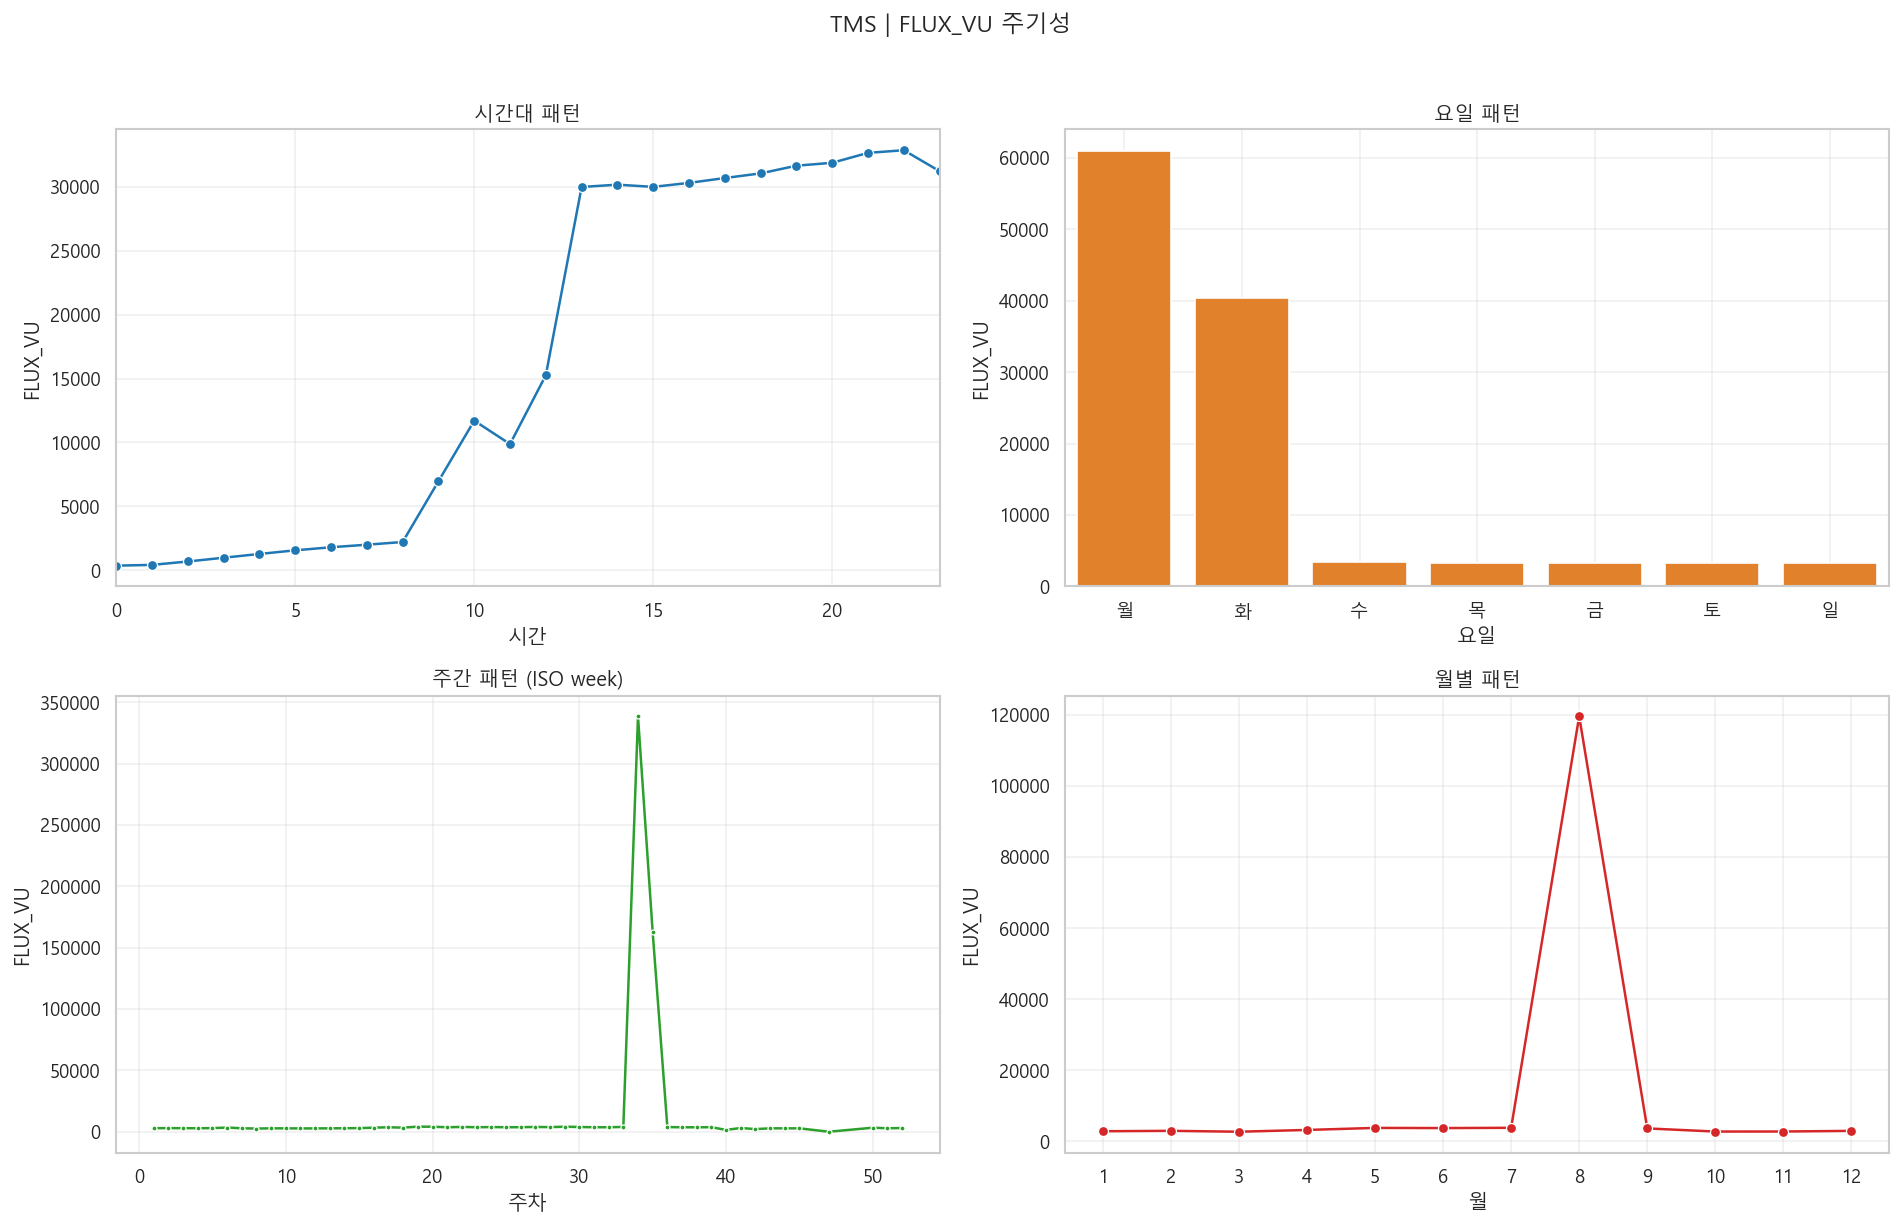

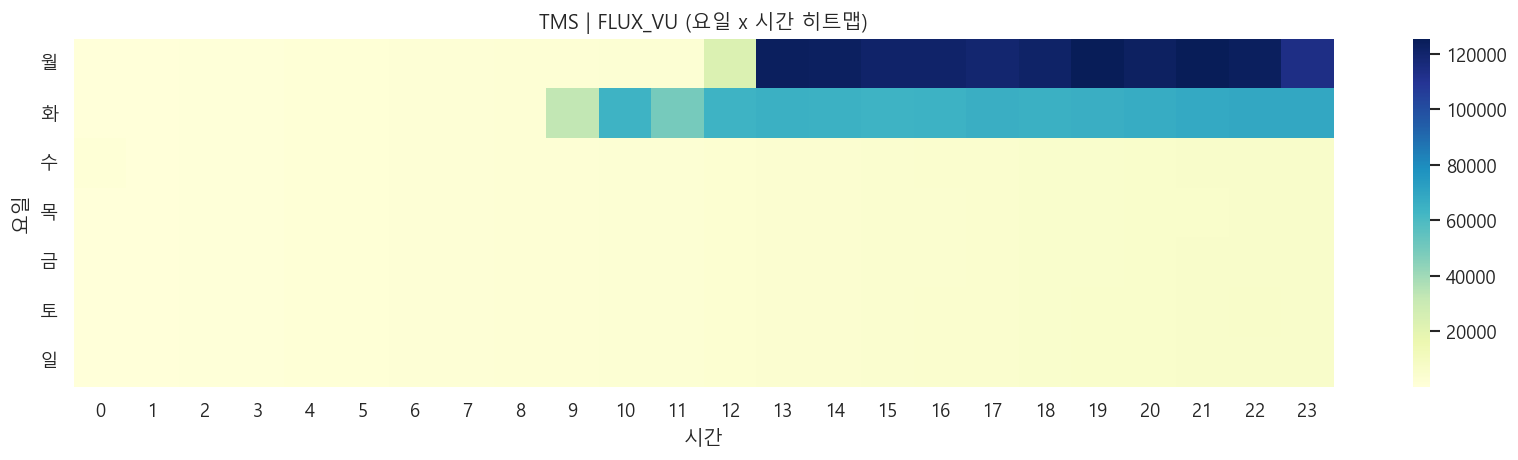

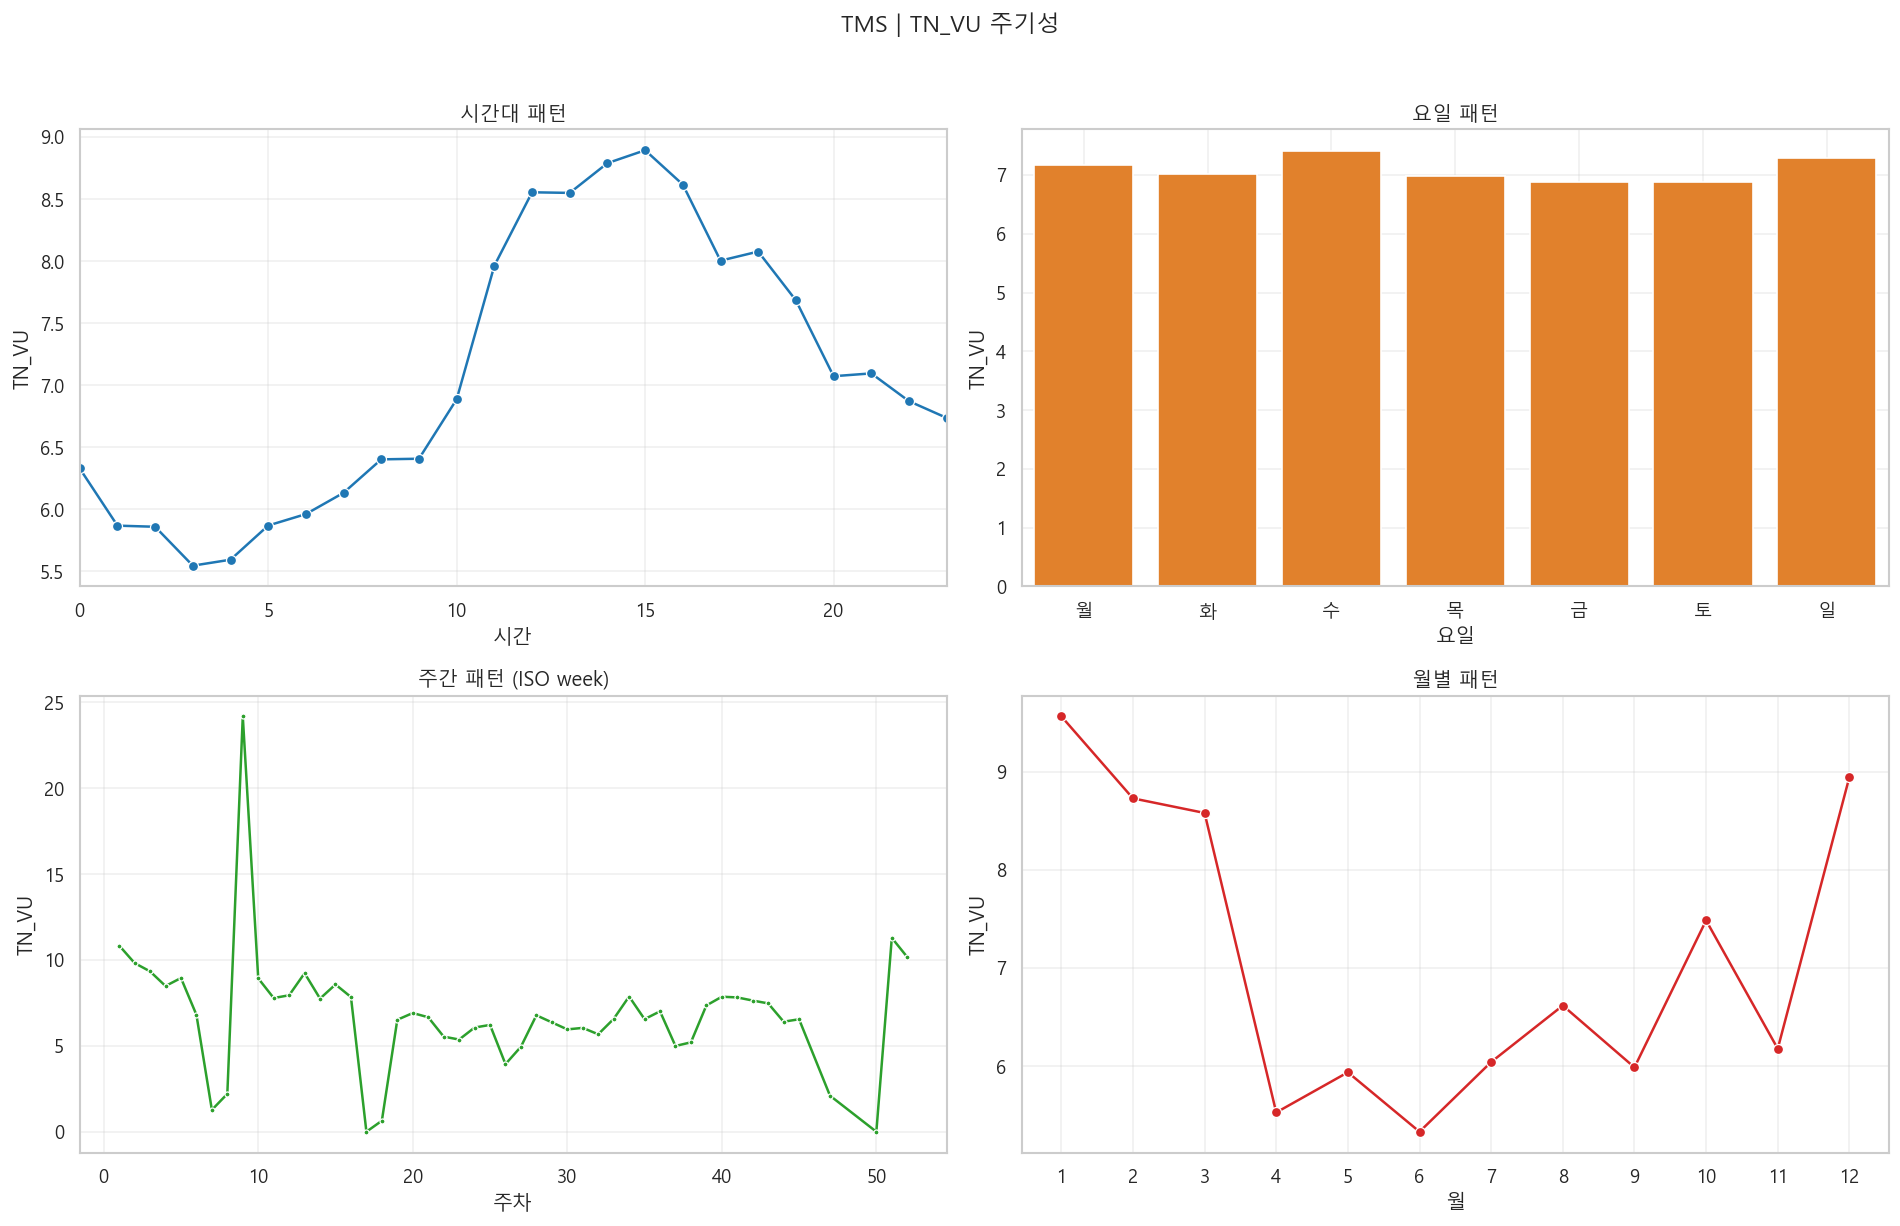

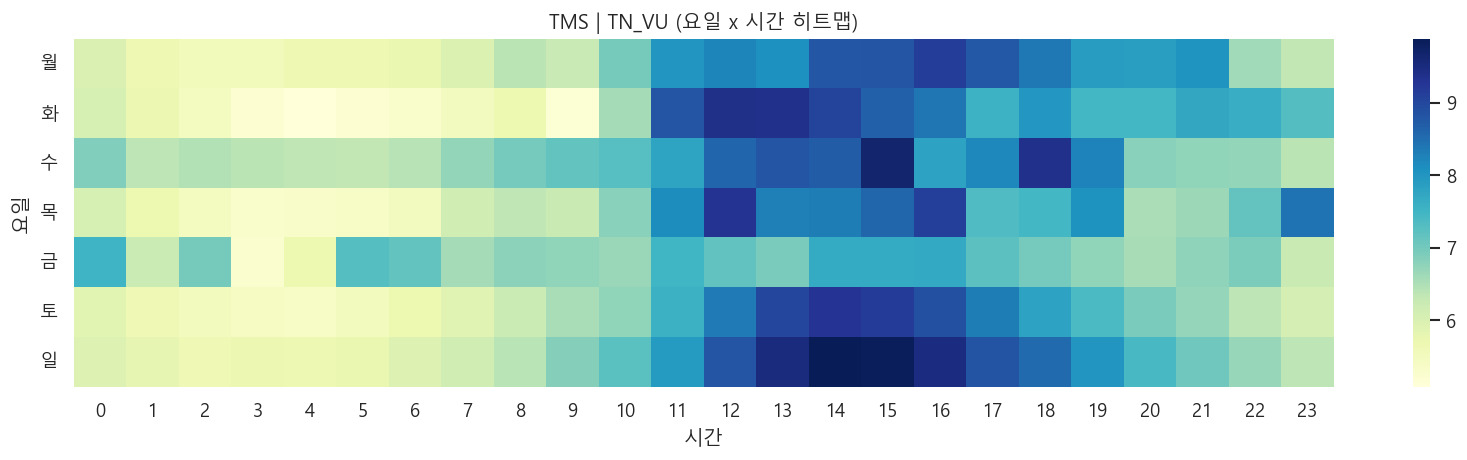

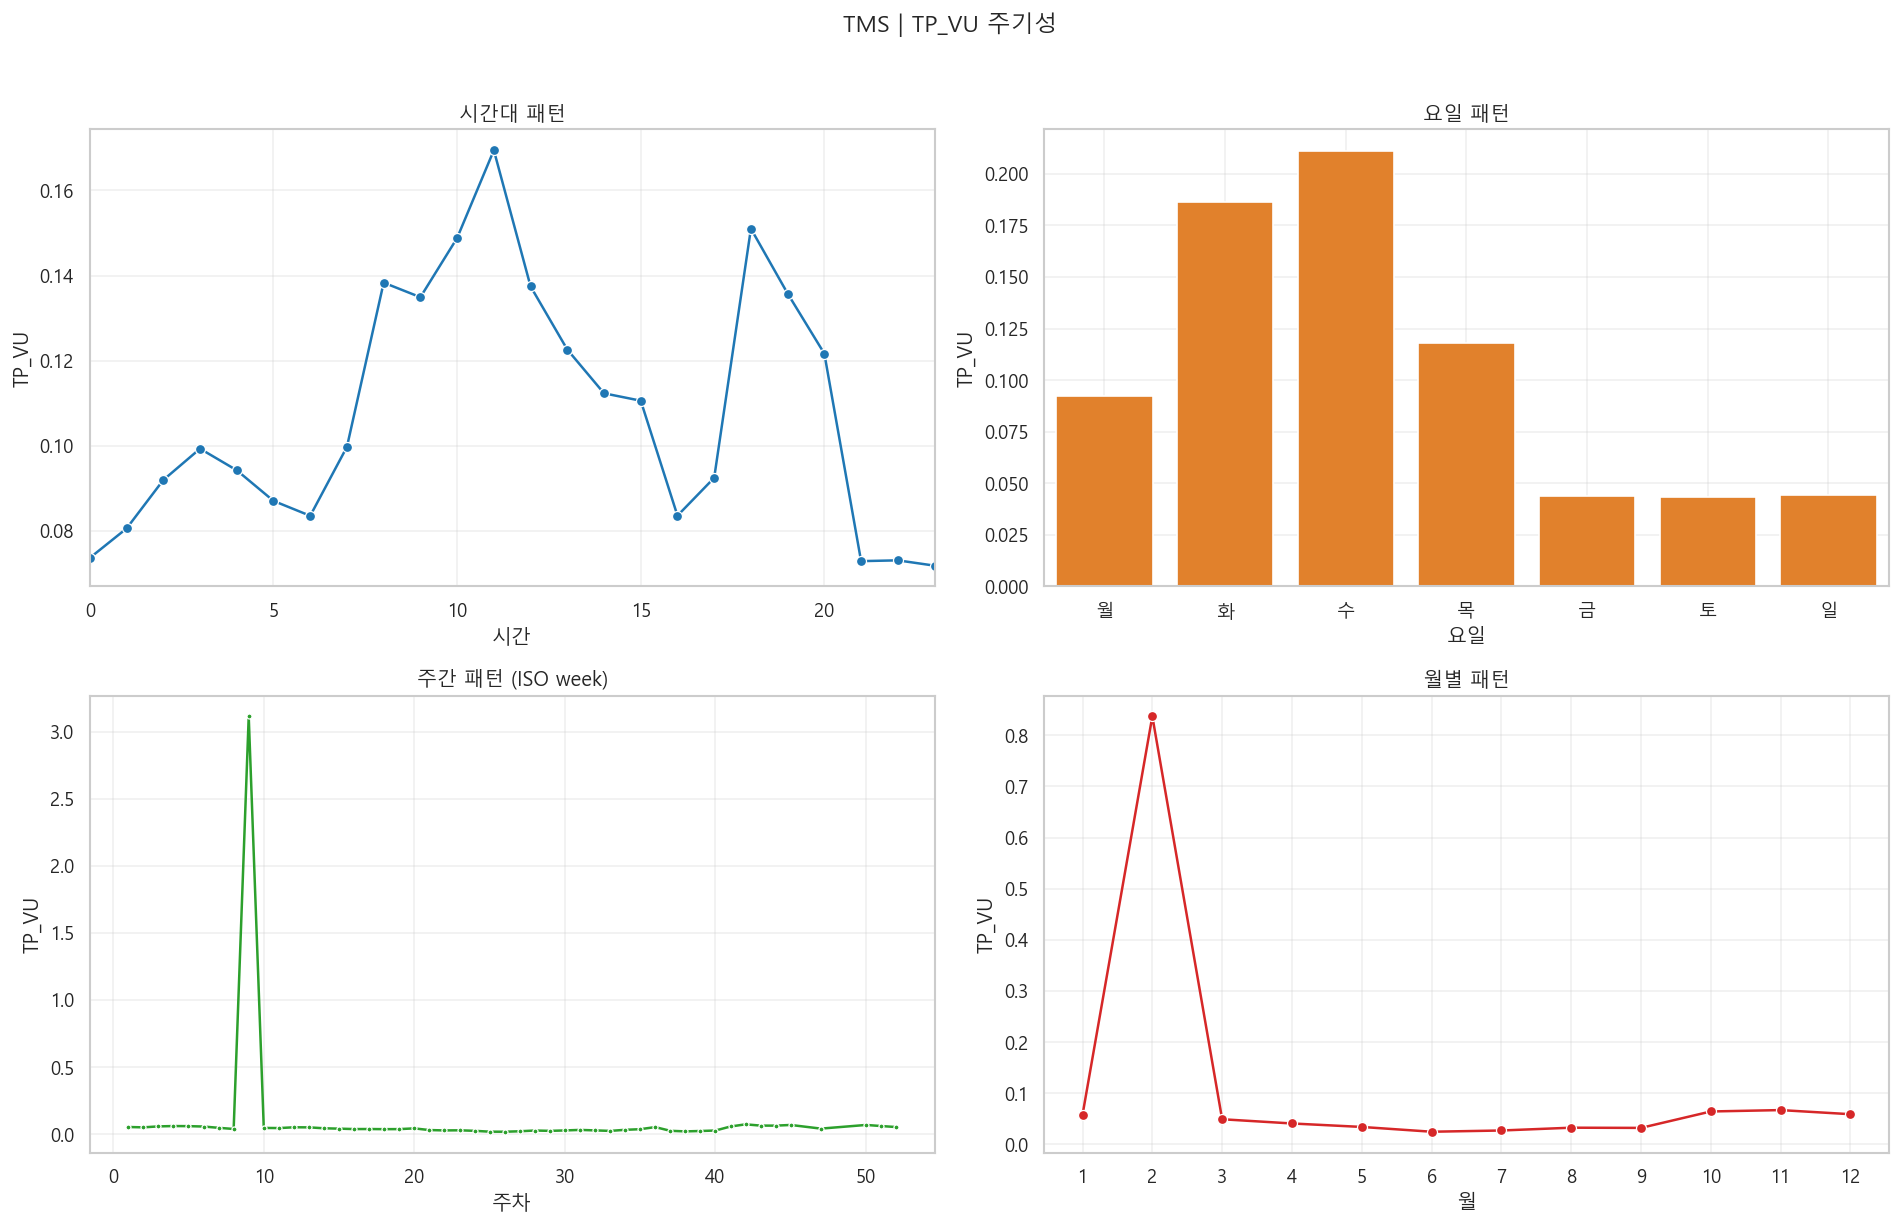

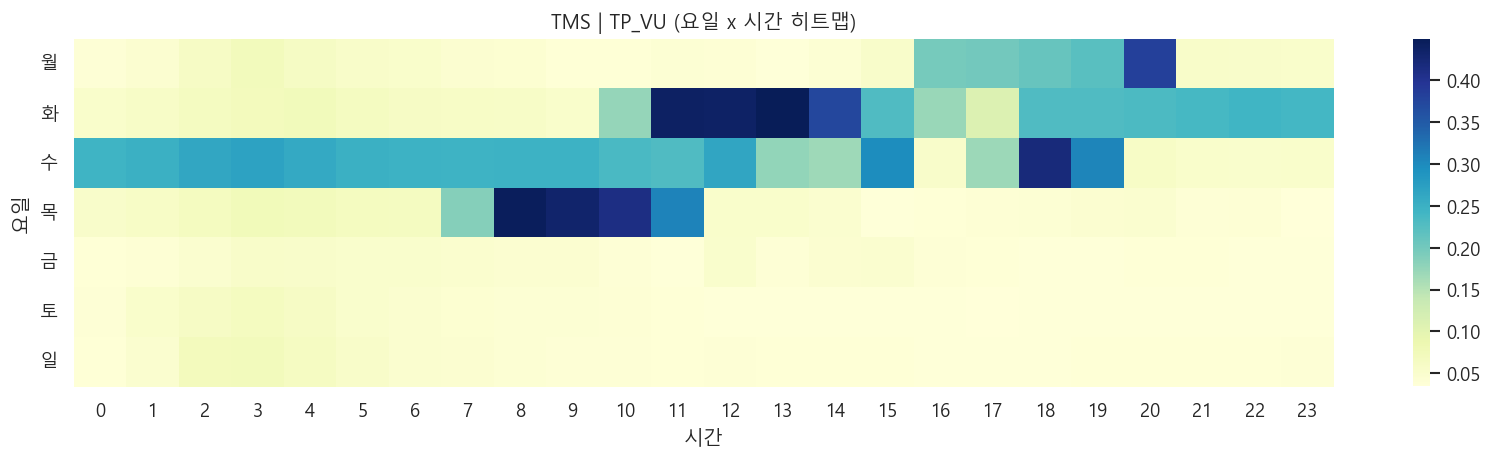

In [9]:
tms_cols = get_numeric_targets(tms_df)
print("TMS targets:", tms_cols)

for col in tms_cols:
    plot_periodicity(tms_df, col, "TMS")
    plot_hour_weekday_heatmap(tms_df, col, "TMS")
